## Pipeline `fft_data_preparation` — Preparação dos dados FFT

**Pipeline:** `fft_data_preparation`  
**Kedro node:** `prepare_all_fft_flights_node`  
**Entrada:** `fft_ready_flights` → `data/02_intermediate/fft_ready/`  
**Saída:** `fft_prepared_flights` → `data/03_primary/fft/`

---

Este notebook é o análogo do `01_00` para o subconjunto de colunas selecionadas em `00_01`.
Aplica as mesmas funções do pipeline `data_preparation`, documentando quais etapas se aplicam
ao dataset FFT e quais são ignoradas por falta de colunas de pré-requisito.

| Etapa | Aplicável? | Observação |
|---|:---:|---|
| `rename_columns` | ✓ | Mesmos mapeamentos — ROS → nomes legíveis |
| `remove_redundant_columns` | ✓ (no-op) | `COLUMNS_TO_DROP` não intersecta as colunas FFT |
| `cut_initial_seconds` | ✓ | Remove artefatos de inicialização do 1º segundo |
| `create_error_features` | ✗ | Requer `pitch_cmd`/`roll_cmd` — ausentes no dataset FFT |
| `rename_final_columns` | ✓ | Padronização final dos nomes restantes |
| `filter_low_variance_columns` | ✓ | Remove sinais com desvio padrão ≤ `min_std_threshold` |

> **Para rodar no Kedro:** `kedro run --pipeline=fft_data_preparation`

## Imports e parâmetros (data_preparation — FFT)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeroespacial_2.pipelines.fft_data_preparation.nodes import prepare_fft_flight
from aeroespacial_2.pipelines.data_preparation.nodes import (
    cut_initial_seconds,
    filter_low_variance_columns,
    remove_redundant_columns,
    rename_columns,
    rename_final_columns,
)

# Espelha conf/base/parameters.yml
FLIGHT_NAME = "carbonZ_2018-07-18-15-53-31_1_engine_failure"
FFT_READY_DATA = "../data/02_intermediate/fft_ready/carbonZ_2018-07-18-15-53-31_1_engine_failure.csv"
CUT_SECONDS = 1.0
MIN_STD_THRESHOLD = 0.0001  # remove colunas com variação abaixo deste threshold

## Etapas do pipeline — redução de colunas

Rastreamos o shape após cada etapa.  
`create_error_features` é omitida: ela exige colunas de atitude (`pitch_cmd`, `roll_cmd`, etc.)
que não fazem parte do subconjunto FFT selecionado em `00_01`.

In [2]:
df_fft_ready = pd.read_csv(FFT_READY_DATA)

steps = []

df_p = df_fft_ready.copy()
steps.append(("fft_ready (entrada)", df_p.shape))

df_p = rename_columns(df_p, FLIGHT_NAME)
steps.append(("rename_columns", df_p.shape))

before_drop = df_p.shape[1]
df_p = remove_redundant_columns(df_p)
steps.append((f"remove_redundant_columns (no-op: -{before_drop - df_p.shape[1]} cols)", df_p.shape))

df_p = cut_initial_seconds(df_p, CUT_SECONDS)
steps.append(("cut_initial_seconds", df_p.shape))

# create_error_features ignorada: pitch_cmd / roll_cmd / vel.des_* ausentes no dataset FFT
steps.append(("create_error_features (IGNORADA — colunas ausentes)", df_p.shape))

df_p = rename_final_columns(df_p)
steps.append(("rename_final_columns", df_p.shape))

df_p = filter_low_variance_columns(df_p, MIN_STD_THRESHOLD)
steps.append(("filter_low_variance_columns ✓", df_p.shape))

df_prepared_fft = df_p

print(f"{'Etapa':<52} {'linhas':>8} {'colunas':>8}")
print("-" * 72)
for name, (rows, cols) in steps:
    print(f"{name:<52} {rows:>8,} {cols:>8}")

Etapa                                                  linhas  colunas
------------------------------------------------------------------------
fft_ready (entrada)                                    26,183       10
rename_columns                                         26,183       10
remove_redundant_columns (no-op: -0 cols)              26,183       10
cut_initial_seconds                                    25,994       10
create_error_features (IGNORADA — colunas ausentes)    25,994       10
rename_final_columns                                   25,994       10
filter_low_variance_columns ✓                          25,994        9


In [8]:
df_prepared_fft

,timestamp,target_fault,imu_accel_x,imu_accel_y,imu_accel_z,mag_x,mag_y,mag_z,aspd_meas
0,0.000000,0.0,-0.147100,0.402073,11.885660,-148000.0,282000.0,-411000.0,18.193935
1,0.004599,0.0,-0.147100,0.402073,11.885660,-148000.0,282000.0,-411000.0,18.210979
2,0.004864,0.0,-0.147100,0.402073,11.885660,-148000.0,282000.0,-411000.0,18.210979
3,0.005244,0.0,-0.147100,0.402073,11.885660,-148000.0,282000.0,-411000.0,18.210979
4,0.007918,0.0,-0.147100,0.402073,11.885660,-148000.0,282000.0,-411000.0,18.210979
...,...,...,...,...,...,...,...,...,...
25989,131.375018,1.0,1.127765,0.225553,10.757895,-76000.0,-240000.0,-408000.0,11.311651
25990,131.375844,1.0,1.127765,0.225553,10.757895,-76000.0,-240000.0,-408000.0,11.311651
25991,131.377763,1.0,1.127765,0.225553,10.757895,-76000.0,-240000.0,-408000.0,11.311651
25992,131.385300,1.0,1.127765,0.225553,10.757895,-76000.0,-240000.0,-408000.0,11.311651


## Checagem visual — desvio padrão das colunas restantes

Após o filtro de variância, **nenhuma coluna deveria ter std = 0**.  
O gráfico confirma isso visualmente para o subconjunto FFT.

- Barras **vermelhas**: `std = 0` (não deveriam existir após o filtro)  
- Barras **laranjas**: `0 < std < min_std_threshold` (zona de alerta configurável)  
- Barras **verdes**: `std ≥ min_std_threshold` (features que passaram no filtro)

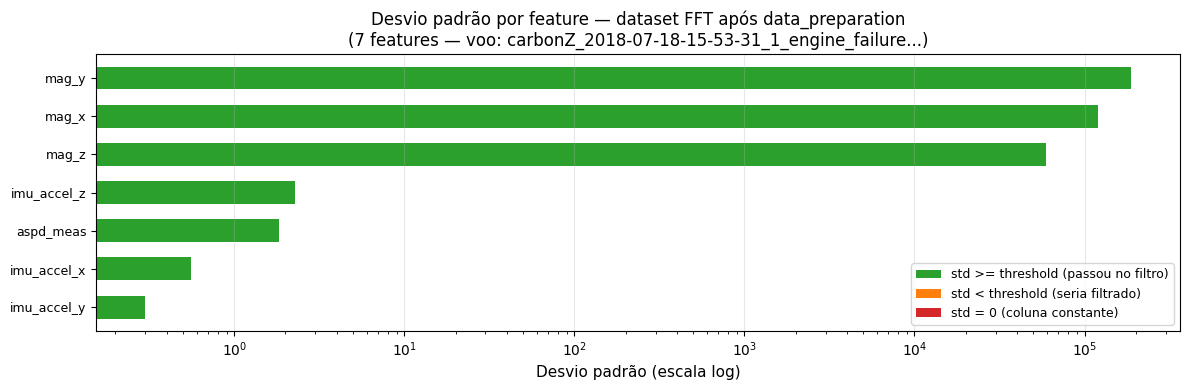

Colunas com std = 0:                  0
Colunas com 0 < std < 0.0: 0
Colunas com std >= 0.0:     7


In [3]:
PROTECTED = {"timestamp", "target_fault"}
feature_cols = [c for c in df_prepared_fft.columns if c not in PROTECTED]
stds = df_prepared_fft[feature_cols].std().sort_values()


def _bar_color(s: float) -> str:
    if s == 0:
        return "tab:red"
    if s < MIN_STD_THRESHOLD:
        return "tab:orange"
    return "tab:green"


colors = [_bar_color(s) for s in stds.values]

fig, ax = plt.subplots(figsize=(12, max(4, len(stds) * 0.5)))
ax.barh(stds.index, stds.values, color=colors, edgecolor="none", height=0.6)

if MIN_STD_THRESHOLD > 0:
    ax.axvline(MIN_STD_THRESHOLD, color="black", linestyle="--", linewidth=1.0,
               label=f"min_std_threshold = {MIN_STD_THRESHOLD}")
    ax.legend(fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Desvio padrão (escala log)", fontsize=11)
ax.set_title(
    f"Desvio padrão por feature — dataset FFT após data_preparation\n"
    f"({len(feature_cols)} features — voo: {FLIGHT_NAME[:45]}...)",
    fontsize=12,
)
ax.tick_params(axis="y", labelsize=9)
ax.grid(True, axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tab:green", label="std >= threshold (passou no filtro)"),
    Patch(facecolor="tab:orange", label="std < threshold (seria filtrado)"),
    Patch(facecolor="tab:red",   label="std = 0 (coluna constante)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

n_zero = (stds == 0).sum()
n_below = ((stds > 0) & (stds < MIN_STD_THRESHOLD)).sum()
print(f"Colunas com std = 0:                  {n_zero}")
print(f"Colunas com 0 < std < {MIN_STD_THRESHOLD}: {n_below}")
print(f"Colunas com std >= {MIN_STD_THRESHOLD}:     {(stds >= MIN_STD_THRESHOLD).sum()}")

## Exploração do threshold — impacto de diferentes valores

O dataset FFT tem poucas colunas (~7 features após a seleção), então a curva é mais íngreme
do que no dataset completo: qualquer aumento no threshold elimina uma fração maior das features.

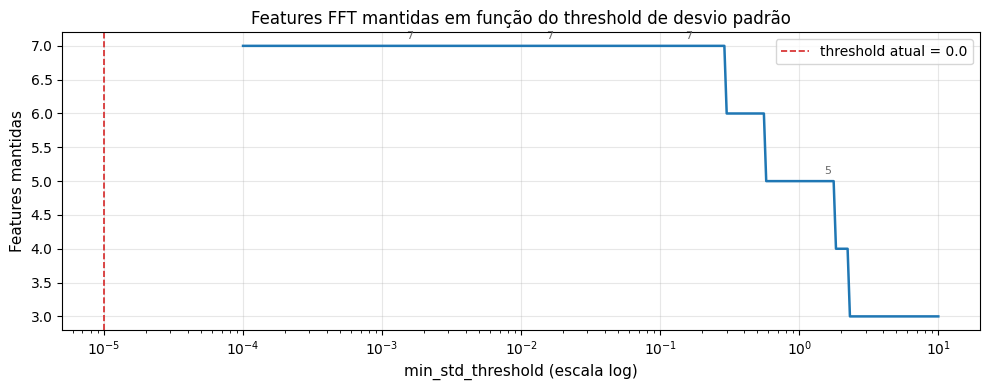

In [4]:
thresholds = np.logspace(-4, 1, 300)
cols_kept = [(t, (stds > t).sum()) for t in thresholds]
t_vals, kept_vals = zip(*cols_kept)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_vals, kept_vals, color="tab:blue", linewidth=1.8)
ax.set_xscale("log")
ax.set_xlabel("min_std_threshold (escala log)", fontsize=11)
ax.set_ylabel("Features mantidas", fontsize=11)
ax.set_title("Features FFT mantidas em função do threshold de desvio padrão", fontsize=12)
ax.grid(True, alpha=0.3)

ax.axvline(max(MIN_STD_THRESHOLD, 1e-5), color="tab:red", linestyle="--", linewidth=1.2,
           label=f"threshold atual = {MIN_STD_THRESHOLD}")
ax.legend(fontsize=10)

for ref in [0.001, 0.01, 0.1, 1.0]:
    n = (stds > ref).sum()
    ax.annotate(f"{n}", xy=(ref, n), xytext=(ref * 1.5, n + 0.1),
                fontsize=8, color="dimgray")

plt.tight_layout()
plt.show()

## Resultado

O DataFrame `df_prepared_fft` contém o subconjunto FFT após todas as etapas de preparação aplicáveis:
renaming, corte do 1º segundo e filtro de variância.

**Diferenças em relação ao `df_prepared` do `01_00`:**
- Nenhuma coluna de erro (`err_pitch`, `err_roll`, etc.) — `create_error_features` foi ignorada
- Apenas sinais com mecanismo físico de periodicidade ligada ao motor (+ altitude)
- Número de features muito menor: adequado para feature engineering espectral (rolling FFT)

Para ajustar o filtro de variância, edite `conf/base/parameters.yml`:
```yaml
data_preparation:
  min_std_threshold: 0.0001
```

---
**Próximo:** `02_00_feature_engineering.ipynb` → features de rolling stats e FFT espectral.

In [5]:
print(f"Shape final (df_prepared_fft): {df_prepared_fft.shape}")
print(f"\nColunas finais:")
for col in df_prepared_fft.columns:
    s = df_prepared_fft[col].std() if col not in PROTECTED else float("nan")
    tag = "(protegida)" if col in PROTECTED else f"std={s:.4f}"
    print(f"  {col:<35} {tag}")

Shape final (df_prepared_fft): (25994, 9)

Colunas finais:
  timestamp                           (protegida)
  target_fault                        (protegida)
  imu_accel_x                         std=0.5583
  imu_accel_y                         std=0.3000
  imu_accel_z                         std=2.2661
  mag_x                               std=119214.3965
  mag_y                               std=186923.2615
  mag_z                               std=59025.5867
  aspd_meas                           std=1.8364


## Visualizando colunas restantes

Evento de falha detectado em t = 115.31 s


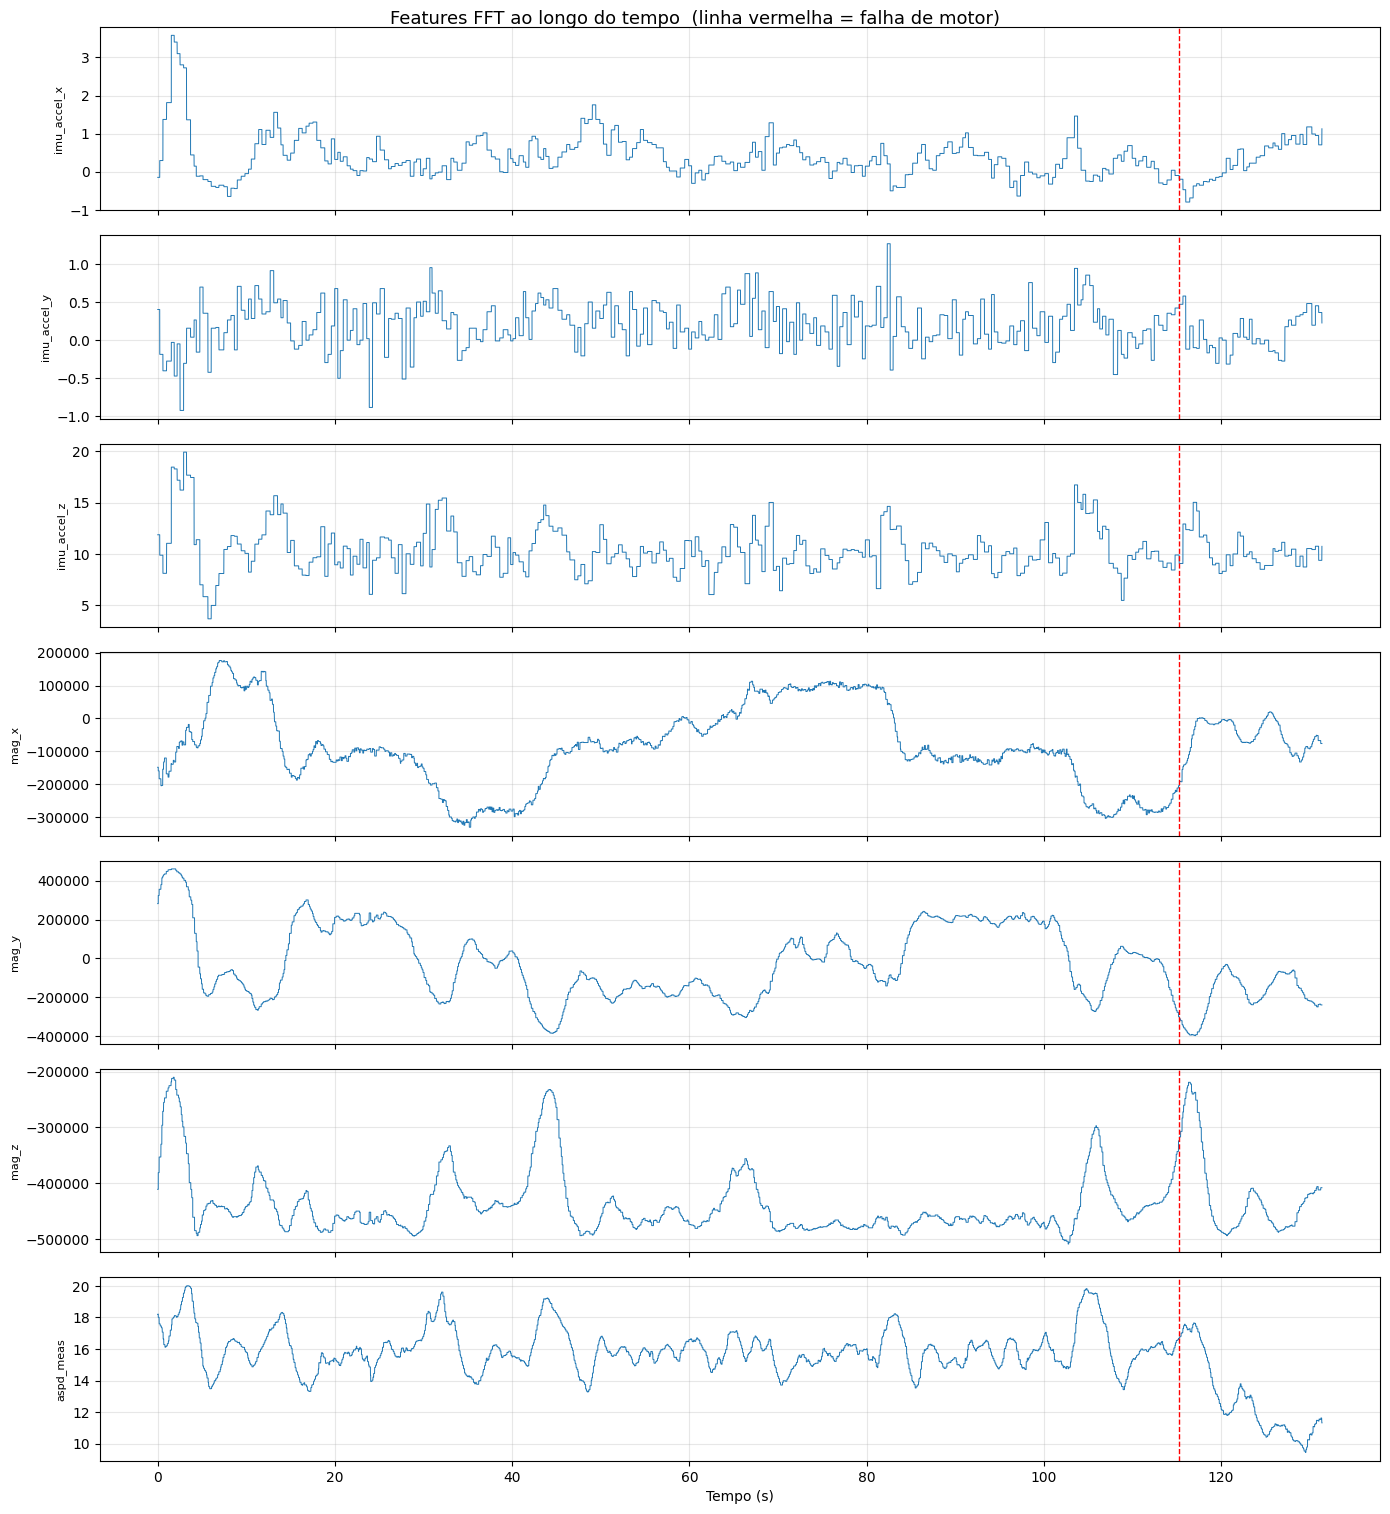

In [6]:
cols_to_plot = [c for c in df_prepared_fft.columns if c not in PROTECTED]
n = len(cols_to_plot)

# Detecta instante de falha (se presente)
failure_time = None
if "target_fault" in df_prepared_fft.columns:
    fault_mask = df_prepared_fft["target_fault"] > 0.5
    if fault_mask.any():
        failure_time = df_prepared_fft.loc[fault_mask, "timestamp"].min()
        print(f"Evento de falha detectado em t = {failure_time:.2f} s")

fig, axes = plt.subplots(n, 1, figsize=(14, 2.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.plot(df_prepared_fft["timestamp"], df_prepared_fft[col],
            linewidth=0.7, color="tab:blue")
    if failure_time is not None:
        ax.axvline(failure_time, color="red", linestyle="--", linewidth=1.0)
    ax.set_ylabel(col, fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tempo (s)")
plt.suptitle(
    "Features FFT ao longo do tempo  (linha vermelha = falha de motor)",
    fontsize=13,
)
plt.tight_layout()
plt.show()